# Fase 1 - Carga y sincronización de datos (EuRoC MAV, formato ASL)

Este fichero está escrito con celdas `# %%`, así que funciona de tres formas:
  - como script:            `python fase1_carga_sincronizacion.py`
  - como notebook en VSCode: se abre directamente con celdas ejecutables
  - como .ipynb:            `jupytext --to notebook fase1_carga_sincronizacion.py`

Objetivo: terminar con, para cada frame de cámara, (a) el bloque de muestras de
IMU que le corresponde y (b) la pose de ground truth interpolada en su instante.

NO hay algoritmos de VIO aquí. Solo datos, tiempos y gráficas de cordura.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from scipy.spatial.transform import Rotation, Slerp
from scipy.ndimage import uniform_filter1d

In [2]:
# Definir las rutas
MAV0 = Path("../data/MH_01_easy/mav0").expanduser()
SALIDA = Path("../results/MH_01_easy/fase1_sync.npz").expanduser()
 
np.set_printoptions(precision=4, suppress=True)

In [3]:
for rel in ["imu0/data.csv", "cam0/data.csv", "cam0/sensor.yaml",
            "imu0/sensor.yaml", "state_groundtruth_estimate0/data.csv"]:
    assert (MAV0 / rel).exists(), f"falta {MAV0 / rel}"
print("Todos los ficheros esperados están en su sitio.")

Todos los ficheros esperados están en su sitio.



## 1.1 - Lectura de los CSV

Detalle que cuesta una hora de depuración si no se ve: la primera línea de los
CSV de EuRoC empieza por `#`. Con `comment="#"` pandas la convierte en línea
vacía y la salta, así que **el fichero ya no tiene cabecera**: hay que pasar
`header=None`. Si pones `header=0`, pandas usa la primera fila de DATOS como
cabecera y la pierdes.

Los timestamps son enteros de 64 bits en NANOSEGUNDOS. Se leen como `int64` y
no se convierten a float todavía (ver celda 1.2).

In [4]:
COLS_IMU = ["t_ns", "wx", "wy", "wz", "ax", "ay", "az"]  # GIRO primero, ACELERÓMETRO segundo
COLS_CAM = ["t_ns", "filename"]
COLS_GT = ["t_ns",
           "px", "py", "pz",           # posición en el frame world [m]
           "qw", "qx", "qy", "qz",     # cuaternión ESCALAR PRIMERO
           "vx", "vy", "vz",           # velocidad en el frame world [m/s]
           "bwx", "bwy", "bwz",        # bias del giroscopio [rad/s]
           "bax", "bay", "baz"]        # bias del acelerómetro [m/s^2]

In [5]:
def leer_csv_euroc(path, columnas):
    df = pd.read_csv(path, comment="#", header=None, names=columnas)
    df["t_ns"] = df["t_ns"].astype(np.int64)
    return df

In [6]:
imu_df = leer_csv_euroc(MAV0 / "imu0/data.csv", COLS_IMU)
cam_df = leer_csv_euroc(MAV0 / "cam0/data.csv", COLS_CAM)
gt_df = leer_csv_euroc(MAV0 / "state_groundtruth_estimate0/data.csv", COLS_GT)

In [7]:
print(f"IMU:    {len(imu_df):6d} muestras")
print(f"cam0:   {len(cam_df):6d} frames")
print(f"GT:     {len(gt_df):6d} muestras")

IMU:     36820 muestras
cam0:     3682 frames
GT:      36382 muestras


In [8]:
# Comprobación cruzada: los PNG que hay en disco deben coincidir con el CSV.
n_png = len(list((MAV0 / "cam0/data").glob("*.png")))
assert n_png == len(cam_df), f"descuadre CSV/PNG: {len(cam_df)} vs {n_png}"
print(f"PNGs en disco: {n_png} -> coincide con el csv")

PNGs en disco: 3682 -> coincide con el csv


## 1.2 - Origen de tiempos

Los timestamps son ns desde el epoch: ~1.40e18. Si los divides directamente por
1e9 obtienes ~1.40e9 segundos, y en float64 el espaciado representable ahí es de
~2.4e-7 s. Es decir: **pierdes la resolución de nanosegundos** en cuanto pasas a
segundos absolutos.

La forma correcta: restar el origen EN ENTEROS (int64, exacto) y solo después
dividir. Así trabajas con tiempos relativos de 0 a ~180 s, donde float64 tiene
precisión de ~1e-14 s. De sobra.

Como origen tomamos el primer timestamp de cámara. Es una elección arbitraria
pero hay que fijarla UNA vez y usarla en todas las fases; si en la Fase 5 usas
otro origen, tus comparaciones con el GT saldrán desplazadas.

In [9]:
T0_NS = np.int64(cam_df["t_ns"].iloc[0])
NS = 1e9

In [10]:
def a_segundos(t_ns):
    """ns absolutos (int64) -> segundos relativos a T0_NS (float64)."""
    return (np.asarray(t_ns, dtype=np.int64) - T0_NS) / NS

In [11]:
t_imu = a_segundos(imu_df["t_ns"].to_numpy())
t_cam = a_segundos(cam_df["t_ns"].to_numpy())
t_gt = a_segundos(gt_df["t_ns"].to_numpy())

print(f"T0 = {T0_NS} ns")
print(f"IMU:    [{t_imu[0]:9.4f} , {t_imu[-1]:9.4f}] s   ({1/np.median(np.diff(t_imu)):.1f} Hz)")
print(f"cam0:   [{t_cam[0]:9.4f} , {t_cam[-1]:9.4f}] s   ({1/np.median(np.diff(t_cam)):.2f} Hz)")
print(f"GT:     [{t_gt[0]:9.4f} , {t_gt[-1]:9.4f}] s   ({1/np.median(np.diff(t_gt)):.1f} Hz)")

T0 = 1403636579763555584 ns
IMU:    [  -0.0050 ,  184.0900] s   (200.0 Hz)
cam0:   [   0.0000 ,  184.0500] s   (20.00 Hz)
GT:     [   1.0750 ,  182.9800] s   (200.0 Hz)


Nótese que la IMU empieza ANTES que la cámara (t_imu[0] es negativo) y que el GT no cubre necesariamente todo el rango. Esto es normal y hay que gestionarlo.
 

## 1.3 - Arrays de numpy

A partir de aquí se abandona pandas. Los DataFrames son cómodos para leer, pero
para hacer cuentas quieres arrays contiguos de float64: el indexado es más
rápido y, sobre todo, las operaciones vectoriales y matriciales son directas.

In [12]:
gyro = imu_df[["wx", "wy", "wz"]].to_numpy(dtype=np.float64)      # [rad/s]
accel = imu_df[["ax", "ay", "az"]].to_numpy(dtype=np.float64)     # [m/s^2]

gt_p = gt_df[["px", "py", "pz"]].to_numpy(dtype=np.float64)       # [m]
gt_v = gt_df[["vx", "vy", "vz"]].to_numpy(dtype=np.float64)       # [m/s]
gt_bw = gt_df[["bwx", "bwy", "bwz"]].to_numpy(dtype=np.float64)   # [rad/s]
gt_ba = gt_df[["bax", "bay", "baz"]].to_numpy(dtype=np.float64)   # [m/s^2]

### CONVERSIÓN DE CUATERNIONES.
EuRoC guarda (w, x, y, z) = escalar primero.

scipy.spatial.transform.Rotation.from_quat espera (x, y, z, w) = escalar último.

Confundirlos no lanza ningún error: simplemente produce rotaciones incorrectas.

Este reordenado explícito es de las líneas más importantes del fichero.

In [13]:
# RECUBRIMIENTO DOBLE: q y -q representan LA MISMA rotación. El fichero de GT
# puede cambiar de signo de una muestra a la siguiente sin que eso signifique
# nada físico. Para SLERP da igual (scipy trabaja con la rotación relativa),
# pero cualquier gráfica de componentes o diferencia finita sobre q saldría con
# saltos de 2 unidades. Se fuerza continuidad de signo una vez, aquí.

def signo_continuo(q):
    """Alinea el signo de cada cuaternión con el de su predecesor."""
    q = np.array(q, dtype=float, copy=True)
    producto = np.sum(q[1:] * q[:-1], axis=1)
    flip = np.cumprod(np.where(producto < 0.0, -1.0, 1.0))
    q[1:] *= flip[:, None]
    return q

In [14]:
q_wxyz = gt_df[["qw", "qx", "qy", "qz"]].to_numpy(dtype=np.float64)
assert np.allclose(np.linalg.norm(q_wxyz, axis=1), 1.0, atol=1e-3), "cuaterniones no normalizados"

n_saltos = int(np.sum(np.sum(q_wxyz[1:] * q_wxyz[:-1], axis=1) < 0.0))
q_wxyz = signo_continuo(q_wxyz)
print(f"Cambios de signo corregidos en el GT: {n_saltos}")

q_xyzw = q_wxyz[:, [1, 2, 3, 0]]
gt_R = Rotation.from_quat(q_xyzw)

Cambios de signo corregidos en el GT: 0


In [15]:
# Rutas absolutas de las imágenes. NO se cargan ahora: eso es la Fase 4.
# Aquí solo se guarda la ruta para poder abrirla luego por índice de frame.
rutas_img = np.array([str(MAV0 / "cam0/data" / f.strip()) for f in cam_df["filename"]])
assert Path(rutas_img[0]).exists(), f"no encuentro {rutas_img[0]}"

## 1.4 - Gráficas de cordura del ground truth

Antes de asociar nada, mira los datos. Es la forma más rápida de detectar un
error de parseo: si la trayectoria sale como un garabato, si la escala está en
miles de metros o si hay discontinuidades no físicas, el problema está en la
lectura, no en tu algoritmo.

CUIDADO con una tentación: `pz` negativa NO es un error. El origen del marco
world de EuRoC es arbitrario (lo fija el estimador offline que genera el GT, no
el suelo del Machine Hall), así que z < 0 sólo significa "por debajo de un
origen que está en el aire". La validación seria del parseo no es mirar el signo
de z, es el test de gravedad de la sección 1.6b.


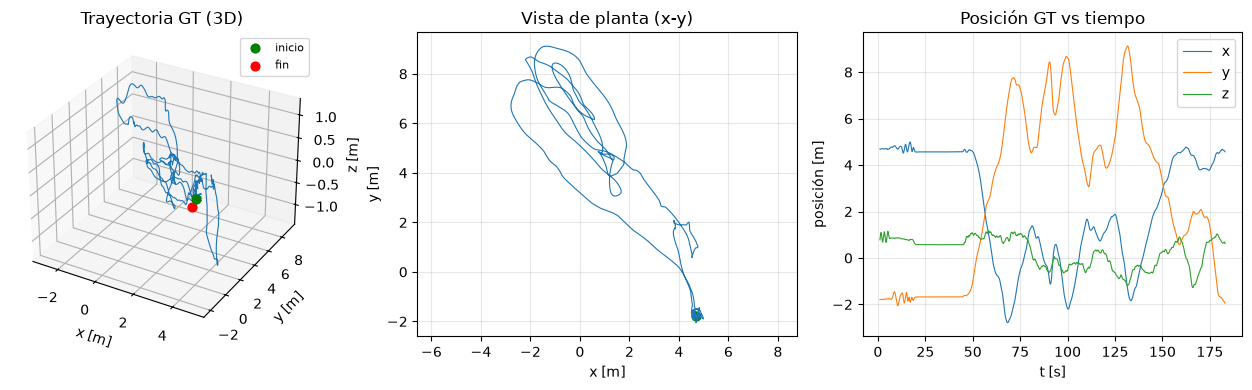

In [16]:
fig = plt.figure(figsize=(13, 4))
 
ax = fig.add_subplot(131, projection="3d")
ax.plot(gt_p[:, 0], gt_p[:, 1], gt_p[:, 2], lw=0.8)
ax.scatter(*gt_p[0], c="g", s=40, label="inicio")
ax.scatter(*gt_p[-1], c="r", s=40, label="fin")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_zlabel("z [m]")
ax.set_title("Trayectoria GT (3D)")
ax.legend(fontsize=8)
 
ax = fig.add_subplot(132)
ax.plot(gt_p[:, 0], gt_p[:, 1], lw=0.8)
ax.scatter(gt_p[0, 0], gt_p[0, 1], c="g", s=40)
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
ax.set_title("Vista de planta (x-y)")
ax.axis("equal"); ax.grid(alpha=0.3)
 
ax = fig.add_subplot(133)
for i, nombre in enumerate("xyz"):
    ax.plot(t_gt, gt_p[:, i], lw=0.8, label=nombre)
ax.set_xlabel("t [s]"); ax.set_ylabel("posición [m]")
ax.set_title("Posición GT vs tiempo")
ax.legend(); ax.grid(alpha=0.3)
 
plt.tight_layout()
plt.show()

In [17]:
recorrido = np.linalg.norm(np.diff(gt_p, axis=0), axis=1).sum()

print(f"Recorrido total: {recorrido:.1f} m en {t_gt[-1] - t_gt[0]:.1f} s")
print(f"Velocidad media: {recorrido / (t_gt[-1] - t_gt[0]):.2f} m/s")
print(f"Velocidad máxima (GT): {np.linalg.norm(gt_v, axis=1).max():.2f} m/s")

Recorrido total: 80.6 m en 181.9 s
Velocidad media: 0.44 m/s
Velocidad máxima (GT): 2.01 m/s


## 1.5 - Gráficas de cordura de la IMU

Dos cosas que buscar:
  1. Que la norma del acelerómetro esté en torno a 9.81 al principio (dron en
     reposo). Valida a la vez las unidades y el orden de columnas.
  2. Que el bias del GT sea pequeño pero NO cero. El bias es lo que hace que la
     integración pura derive, y en la Fase 6 será parte del estado a estimar.

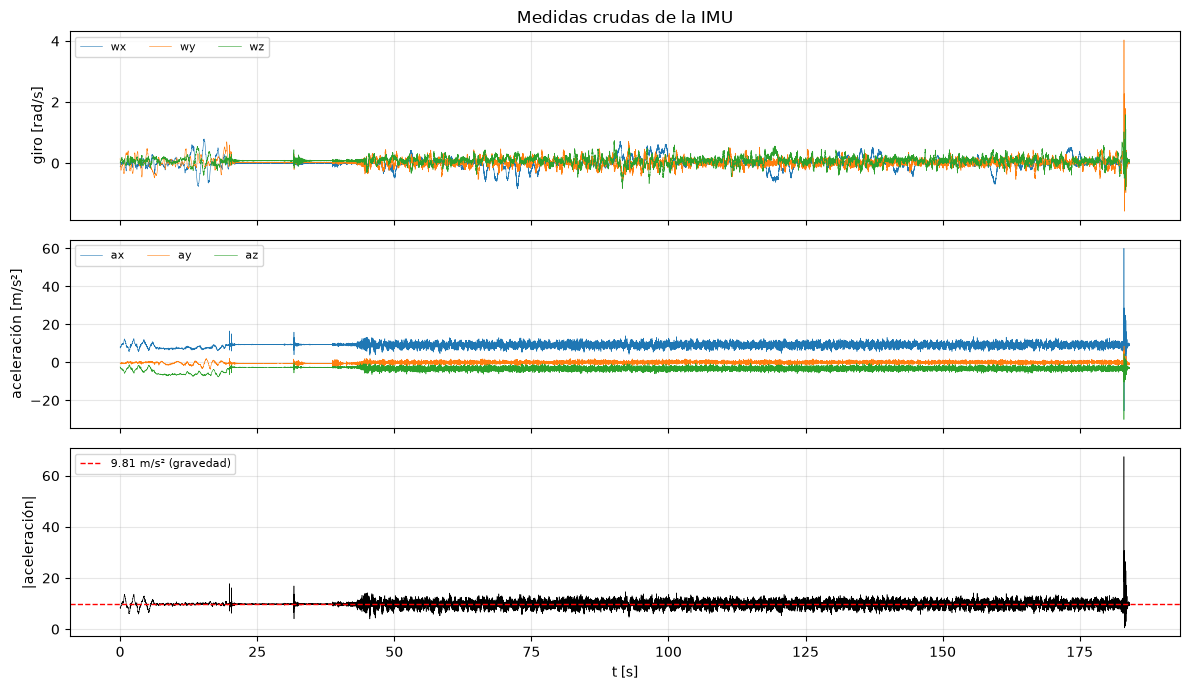

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
 
for i, nombre in enumerate("xyz"):
    axes[0].plot(t_imu, gyro[:, i], lw=0.4, label=f"w{nombre}")
axes[0].set_ylabel("giro [rad/s]"); axes[0].legend(ncol=3, fontsize=8); axes[0].grid(alpha=0.3)
axes[0].set_title("Medidas crudas de la IMU")
 
for i, nombre in enumerate("xyz"):
    axes[1].plot(t_imu, accel[:, i], lw=0.4, label=f"a{nombre}")
axes[1].set_ylabel("aceleración [m/s²]"); axes[1].legend(ncol=3, fontsize=8); axes[1].grid(alpha=0.3)
 
axes[2].plot(t_imu, np.linalg.norm(accel, axis=1), lw=0.4, c="k")
axes[2].axhline(9.81, color="r", ls="--", lw=1, label="9.81 m/s² (gravedad)")
axes[2].set_ylabel("|aceleración|"); axes[2].set_xlabel("t [s]")
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)
 
plt.tight_layout()
plt.show()
 

In [19]:
print("Bias del GT (magnitud media):")
print(f"  giroscopio:    {np.linalg.norm(gt_bw, axis=1).mean():.6f} rad/s")
print(f"  acelerómetro:  {np.linalg.norm(gt_ba, axis=1).mean():.6f} m/s²")

Bias del GT (magnitud media):
  giroscopio:    0.081301 rad/s
  acelerómetro:  0.158921 m/s²


## 1.6 - Detección de los tramos en reposo

El dron NO está necesariamente quieto al principio de la secuencia. En MH_01 la
estructura real es:

  - 0-20 s   : alguien manipula el dron a mano
  - 20-43 s  : reposo real, motores parados   <- esto es lo que buscamos
  - 43-50 s  : motores en marcha, vibración de hélices
  - 50 s-fin : vuelo

Un detector que asuma "el reposo está al principio" se queda con el tramo
equivocado y estima un bias que es basura. El criterio correcto tiene tres
piezas:

  1. DESVIACIÓN TÍPICA, no valor absoluto. El valor absoluto de la medida
     incluye el bias; su desviación típica no. Y al revés: una vibración de
     media cero no sube |w| pero sí sube std(w).
  2. LAS TRES CONDICIONES A LA VEZ: giro quieto, acelerómetro quieto Y
     |a| ~ 9.81. Sólo con el giro, una traslación pura o una caída libre
     pasarían por "estático".
  3. EL TRAMO MÁS LARGO, no el primero.

QUÉ SALE Y QUÉ NO SALE DEL REPOSO. En reposo la medida es

    a_medida = -R_wb^T g_w + b_a

Son 3 ecuaciones con 3 incógnitas de b_a más 2 de la dirección de la gravedad
(el módulo es conocido) = 5. Por tanto:

  - SÍ sale el bias del giróscopo: la media del giro ES el bias.
  - SÍ salen roll y pitch iniciales, ASUMIENDO b_a = 0. El yaw es inobservable
    con la gravedad sola.
  - NO sale el bias del acelerómetro: está acoplado con la gravedad y no hay
    forma de separarlos sin movimiento. VINS-Mono hace exactamente lo mismo:
    su vector de inicialización es {v_bk, g_c0, s} y NO incluye b_a.

Y un corolario para la Fase 3: NO arranques el estimador aquí. Sin movimiento no
hay paralaje ni excitación en aceleración, así que ni la escala métrica ni b_a
son observables.

In [20]:
VENTANA_S    = 0.2    # s, longitud de la ventana deslizante
THR_STD_GIRO = 0.02   # rad/s
THR_STD_ACC  = 0.25   # m/s^2
THR_G        = 0.5    # m/s^2, desvío admitido de |a| respecto a la gravedad
DUR_MIN_S    = 1.0    # s, tramos más cortos se descartan
MARGEN_S     = 0.5    # s, recorte por cada lado del tramo
G_NOMINAL    = 9.81   # m/s^2

# Orden de magnitud de los umbrales: con las densidades de ruido del sensor.yaml
# de EuRoC (giro 1.70e-4 rad/s/sqrt(Hz), acel 2.00e-3 m/s^2/sqrt(Hz)) y fs=200 Hz,
# el sigma por muestra es ~2.4e-3 rad/s y ~2.8e-2 m/s^2. Los umbrales de arriba
# están a ~8 sigma: holgados frente al ruido, pero muy por debajo de cualquier
# movimiento real.

In [21]:
def std_movil(x, W):
    """Desviación típica en ventana deslizante, por columnas. Coste O(n)."""
    m = uniform_filter1d(x, W, axis=0, mode="nearest")
    m2 = uniform_filter1d(x * x, W, axis=0, mode="nearest")
    return np.sqrt(np.maximum(m2 - m * m, 0.0))   # el max evita raíces de -1e-18

def tramos_contiguos(mask):
    """Lista de pares (ini, fin) de todos los tramos contiguos de True."""
    d = np.diff(mask.astype(np.int8))
    ini = list(np.flatnonzero(d == 1) + 1)
    fin = list(np.flatnonzero(d == -1) + 1)
    if mask[0]:
        ini = [0] + ini
    if mask[-1]:
        fin = fin + [len(mask)]
    return list(zip(ini, fin))

In [22]:
FS_IMU = 1.0 / np.median(np.diff(t_imu))
W = max(3, int(round(VENTANA_S * FS_IMU)))

std_giro = std_movil(gyro, W).max(axis=1)      # el peor de los tres ejes
std_accel = std_movil(accel, W).max(axis=1)
desvio_g = np.abs(uniform_filter1d(np.linalg.norm(accel, axis=1), W, mode="nearest") - G_NOMINAL)

print(f"Ventana de {W} muestras ({VENTANA_S:.2f} s a {FS_IMU:.1f} Hz)")

Ventana de 40 muestras (0.20 s a 200.0 Hz)


In [23]:
en_reposo = (std_giro < THR_STD_GIRO) & (std_accel < THR_STD_ACC) & (desvio_g < THR_G)

# El filtro de ventana "contagia" la transición hacia dentro del tramo, así que
# se recorta MARGEN_S por cada lado antes de quedarse con nada.
tramos = []
for i0, i1 in tramos_contiguos(en_reposo):
    if t_imu[i1 - 1] - t_imu[i0] < DUR_MIN_S:
        continue
    j0 = np.searchsorted(t_imu, t_imu[i0] + MARGEN_S)
    j1 = np.searchsorted(t_imu, t_imu[i1 - 1] - MARGEN_S)
    if (j1 - j0) > 0.5 * FS_IMU:
        tramos.append((j0, j1))

tramos.sort(key=lambda r: r[1] - r[0], reverse=True)   # el más largo primero
assert tramos, "ningún tramo en reposo; revisa los umbrales de la celda 27"

In [24]:
print(f"Tramos en reposo encontrados: {len(tramos)}")
for k, (i0, i1) in enumerate(tramos):
    print(f"  [{k}] {t_imu[i0]:7.2f} -> {t_imu[i1-1]:7.2f} s "
          f"({(i1 - i0) / FS_IMU:5.1f} s, {i1 - i0} muestras)")

I0, I1 = tramos[0]
t_est0, t_est1 = t_imu[I0], t_imu[I1 - 1]
print(f"\nTramo elegido (el más largo): [{t_est0:.2f}, {t_est1:.2f}] s")

Tramos en reposo encontrados: 2
  [0]   21.82 ->   30.98 s (  9.2 s, 1833 muestras)
  [1]   34.43 ->   38.14 s (  3.7 s, 742 muestras)

Tramo elegido (el más largo): [21.82, 30.98] s


In [25]:
n_est = I1 - I0
bias_giro_est = gyro[I0:I1].mean(axis=0)
sigma_bias_giro = gyro[I0:I1].std(axis=0) / np.sqrt(n_est)   # incertidumbre de la media
accel_medio_est = accel[I0:I1].mean(axis=0)

# En reposo el acelerómetro mide -g expresada en body, así que la gravedad es
# la opuesta. Escalada al módulo nominal para no arrastrar el bias residual.
g_body = -accel_medio_est / np.linalg.norm(accel_medio_est) * G_NOMINAL
arriba = -g_body / G_NOMINAL
roll0 = np.arctan2(arriba[1], arriba[2])
pitch0 = np.arctan2(-arriba[0], np.hypot(arriba[1], arriba[2]))

# OJO CON sigma_bias_giro: es sigma/sqrt(n), que sólo modela RUIDO BLANCO. El
# bias es un random walk, así que promediar más muestras no reduce su
# inestabilidad y la precisión se satura muy por encima de este número. En la
# práctica sale ~13 sigma de discrepancia contra el GT. No es un error: es que
# la fórmula subestima. Para un prior sobre b_g en la Fase 3 usa
# gyroscope_random_walk del sensor.yaml, NO esto.
print(f"Estimaciones del tramo estático ({n_est} muestras, {n_est / FS_IMU:.1f} s):")
print(f"  bias del giróscopo   = {bias_giro_est} rad/s")
print(f"  sigma/sqrt(n)        = {sigma_bias_giro} rad/s   <- optimista, ver nota")
print(f"  acelerómetro medio   = {accel_medio_est} m/s²")
print(f"  |acelerómetro medio| = {np.linalg.norm(accel_medio_est):.4f} m/s²")
print(f"  gravedad en body     = {g_body} m/s²")
print(f"  roll0  = {np.degrees(roll0):+.2f} deg")
print(f"  pitch0 = {np.degrees(pitch0):+.2f} deg   (el yaw NO es observable aquí)")

# Validación contra el GT. En el dron real no tendrás esto, pero aquí sí.
m_gt_est = (t_gt >= t_est0) & (t_gt <= t_est1)
if m_gt_est.sum() > 10:
    bias_gt = gt_bw[m_gt_est].mean(axis=0)
    print(f"\nValidación contra el GT ({m_gt_est.sum()} muestras):")
    print(f"  |v_gt| máxima en el tramo = {np.linalg.norm(gt_v[m_gt_est], axis=1).max():.4f} m/s"
          f"   <- debe ser ~0")
    print(f"  bias del GT               = {bias_gt} rad/s")
    print(f"  error de mi estimación    = {np.linalg.norm(bias_giro_est - bias_gt):.2e} rad/s")
else:
    print("\nAviso: el tramo estático cae fuera del rango del GT, no se puede validar.")

Estimaciones del tramo estático (1833 muestras, 9.2 s):
  bias del giróscopo   = [-0.0033  0.0208  0.0797] rad/s
  sigma/sqrt(n)        = [0.0001 0.0001 0.0001] rad/s   <- optimista, ver nota
  acelerómetro medio   = [ 9.4148 -0.524  -2.5789] m/s²
  |acelerómetro medio| = 9.7757 m/s²
  gravedad en body     = [-9.4479  0.5258  2.588 ] m/s²
  roll0  = -168.51 deg
  pitch0 = -74.38 deg   (el yaw NO es observable aquí)

Validación contra el GT (1833 muestras):
  |v_gt| máxima en el tramo = 0.0043 m/s   <- debe ser ~0
  bias del GT               = [-0.0032  0.0213  0.0785] rad/s
  error de mi estimación    = 1.33e-03 rad/s


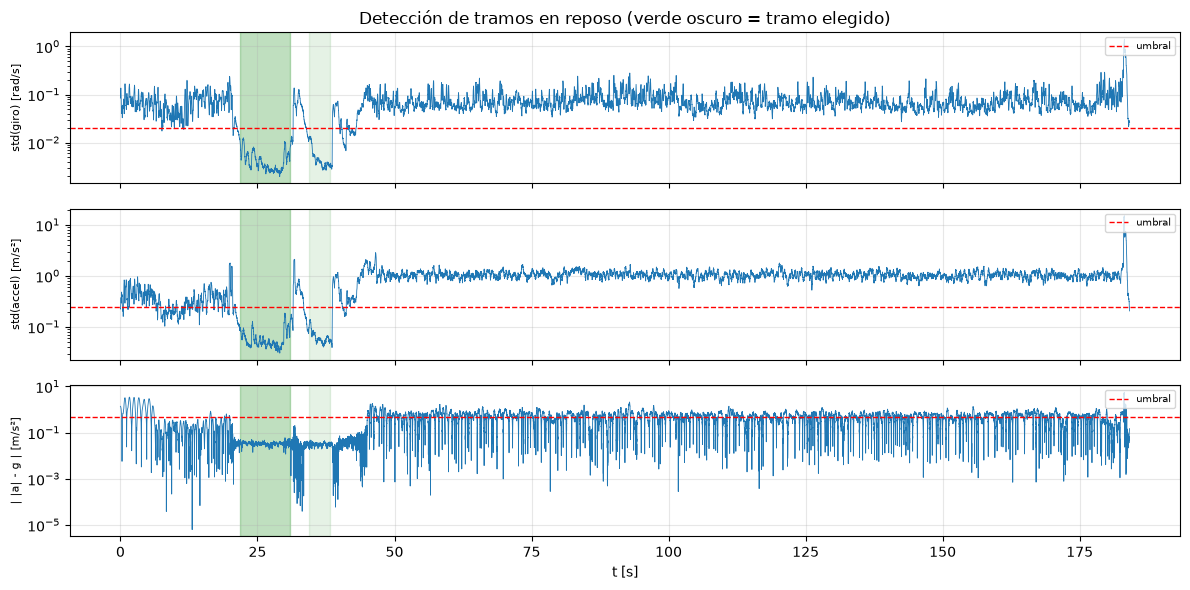

In [26]:
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)

paneles = [(std_giro, THR_STD_GIRO, "std(giro) [rad/s]"),
           (std_accel, THR_STD_ACC, "std(accel) [m/s²]"),
           (desvio_g, THR_G, "| |a| - g | [m/s²]")]

for ax, (y, thr, etiqueta) in zip(axes, paneles):
    ax.plot(t_imu, y, lw=0.6, c="C0")
    ax.axhline(thr, color="r", ls="--", lw=1, label="umbral")
    ax.set_yscale("log")            # los rangos son de varias décadas
    ax.set_ylabel(etiqueta, fontsize=8)
    ax.grid(alpha=0.3); ax.legend(fontsize=7, loc="upper right")
    for k, (i0, i1) in enumerate(tramos):
        ax.axvspan(t_imu[i0], t_imu[i1 - 1], color="g", alpha=0.25 if k == 0 else 0.10)

axes[0].set_title("Detección de tramos en reposo (verde oscuro = tramo elegido)")
axes[2].set_xlabel("t [s]")
plt.tight_layout()
plt.show()

### 1.6b - Test de consistencia: ¿está el world alineado con la gravedad?

En reposo y con b_a ~ 0 se cumple

    R_wb @ a_medida  ~  (0, 0, +9.81)

Un solo número valida CUATRO cosas a la vez:
  - el orden de columnas del CSV (giro antes que acelerómetro)
  - el reordenado del cuaternión wxyz -> xyzw
  - que gt_R es R_wb y no su traspuesta
  - que el marco world del GT está alineado con la gravedad

Si sale cualquier otra cosa, uno de esos cuatro está mal, y arrastrarlo hasta la
Fase 5 cuesta días. Este es el test que sustituye a "mirar si z es negativa".

In [27]:
assert m_gt_est.sum() > 10, "el tramo estático cae fuera del rango del GT"

R_est = gt_R[m_gt_est].mean()                  # media de rotaciones en la variedad
a_world = R_est.as_matrix() @ accel_medio_est
residuo = a_world - np.array([0.0, 0.0, G_NOMINAL])
err_g = np.linalg.norm(residuo)

print(f"R_wb @ a_medida = {a_world} m/s²   (esperado [0, 0, {G_NOMINAL}])")
print(f"residuo         = {residuo} m/s²   (|.| = {err_g:.4f})")
print(f"  componente horizontal = {np.linalg.norm(residuo[:2]):.4f} m/s²"
      f"  ->  {np.degrees(np.arctan2(np.linalg.norm(residuo[:2]), G_NOMINAL)):.2f} deg de inclinación")
assert err_g < 0.5, "world no alineado con la gravedad, o error de convención de marcos"

# ESE RESIDUO NO ES RUIDO, ES EL BIAS DEL ACELERÓMETRO. De la ecuación en reposo
#     R_wb @ a_medida = -g_w + R_wb @ b_a
# se deduce que el residuo tiene que ser exactamente R_wb @ b_a. EuRoC guarda
# b_a en el GT, así que se puede comprobar numéricamente. Esta es la
# demostración de que b_a y la gravedad son indistinguibles en reposo: todo lo
# que puedes hacer es meter b_a dentro de tu estimación de la dirección de g.
ba_gt = gt_ba[m_gt_est].mean(axis=0)
print(f"\nR_wb @ b_a (del GT) = {R_est.as_matrix() @ ba_gt} m/s²   <- comparar con el residuo")
print(f"|b_a| del GT        = {np.linalg.norm(ba_gt):.4f} m/s²")
print(f"desajuste           = {np.linalg.norm(residuo - R_est.as_matrix() @ ba_gt):.4f} m/s²")

# Y el déficit de módulo es el mismo bias proyectado sobre la vertical:
print(f"\n|a| medido = {np.linalg.norm(accel_medio_est):.4f} m/s²"
      f"   vs 9.807 (gravedad local en Zúrich)"
      f"   -> déficit {np.linalg.norm(accel_medio_est) - 9.807:+.4f} m/s²")

R_wb @ a_medida = [-0.0378  0.1422  9.7746] m/s²   (esperado [0, 0, 9.81])
residuo         = [-0.0378  0.1422 -0.0354] m/s²   (|.| = 0.1513)
  componente horizontal = 0.1471 m/s²  ->  0.86 deg de inclinación

R_wb @ b_a (del GT) = [-0.0429  0.1429 -0.0538] m/s²   <- comparar con el residuo
|b_a| del GT        = 0.1586 m/s²
desajuste           = 0.0191 m/s²

|a| medido = 9.7757 m/s²   vs 9.807 (gravedad local en Zúrich)   -> déficit -0.0313 m/s²


### 1.6c - Instante de arranque del estimador

"Fin del reposo" y "puedo arrancar el VIO" son dos cosas distintas. El fin del
reposo es cuando arrancan los motores; el arranque útil es cuando hay traslación
suficiente para generar paralaje. En MH_01 hay ~7 s entre una cosa y la otra.

Aquí se calculan las dos: la que sale sólo de la IMU (que es lo que tendrás en
el dron real) y la que sale del GT (que sirve de referencia para comprobar
cuánto margen hay que añadir).

In [28]:
# BUG DE LA VERSIÓN ANTERIOR: argmax(~en_reposo[I1:]) devuelve la primera
# muestra fuera de reposo TRAS EL TRAMO ELEGIDO, y el tramo elegido no es el
# último. En MH_01 eso daba 31.5 s, que es el golpecito que parte el reposo en
# dos, no los motores.
#
# Los motores no se detectan como "primer movimiento" sino como un SALTO DE
# NIVEL en la vibración: std(accel) pasa de ~0.05 a ~1 m/s² cuando giran las
# hélices, dos órdenes de magnitud. Eso es lo robusto, y es lo que usarás en el
# dron real donde no hay GT que consultar.
THR_VIBRACION = 0.5   # m/s², nivel de std(accel) con hélices en marcha
DUR_MOV_MIN = 2.0     # s, para no disparar con un golpe aislado

vibrando = std_accel > THR_VIBRACION
i_motores = next(j0 for j0, j1 in tramos_contiguos(vibrando)
                 if (j1 - j0) / FS_IMU >= DUR_MOV_MIN)
t_motores = t_imu[i_motores]

# Con el GT (sólo como referencia): primer instante con velocidad apreciable.
UMBRAL_V = 0.10   # m/s
m_mov = (t_gt > t_est1) & (np.linalg.norm(gt_v, axis=1) > UMBRAL_V)
t_despegue = t_gt[np.argmax(m_mov)] if m_mov.any() else np.nan

MARGEN_ARRANQUE = 1.0   # s de colchón sobre el despegue
t_arranque = t_despegue + MARGEN_ARRANQUE

print(f"Motores en marcha (sólo IMU) : t = {t_motores:.2f} s")
print(f"Despegue (|v_gt| > {UMBRAL_V}) : t = {t_despegue:.2f} s")
print(f"Arranque del estimador       : t = {t_arranque:.2f} s")
print(f"  -> frame de cámara más cercano: {int(np.searchsorted(t_cam, t_arranque))}")
assert abs(t_motores - t_despegue) < 10.0, "el detector de motores no cuadra con el despegue del GT"

Motores en marcha (sólo IMU) : t = 43.11 s
Despegue (|v_gt| > 0.1) : t = 44.82 s
Arranque del estimador       : t = 45.82 s
  -> frame de cámara más cercano: 917


## 1.7 - Asociación IMU <-> frames

Este es el corazón de la Fase 1.

La cámara va a 20 Hz y la IMU a 200 Hz, así que entre dos frames consecutivos
hay ~10 muestras de IMU. La estructura que necesitas es: "para propagar del
frame k-1 al frame k, integra ESTAS muestras".

CONVENCIÓN (hay que elegir una y no cambiarla): intervalo semiabierto

      (t_cam[k-1], t_cam[k]]

es decir, se excluye el extremo izquierdo y se incluye el derecho. Así ninguna
muestra de IMU se cuenta en dos intervalos, que es el error que produce esas
derivas "inexplicables" de un pequeño porcentaje.

`np.searchsorted(t_imu, t, side="right")` devuelve cuántas muestras cumplen
t_imu <= t. Llamando a eso `idx[k]`, el bloque del intervalo k es exactamente
el slice `[idx[k-1], idx[k])`.

`searchsorted` es O(log n) por consulta y vectorizado. No hagas esto con un
bucle de máscaras booleanas: sería O(n·m) y tardaría minutos.

In [29]:
idx = np.searchsorted(t_imu, t_cam, side="right")

# Para cada frame k >= 1: rango [ini, fin) de muestras de IMU del interval.
imu_ini = idx[:-1]   # inicio del bloque del frame k (para k = 1..N-1)
imu_fin = idx[1:]    # fin (exclusivo)
n_por_frame = imu_fin - imu_ini

print(f"Frames: {len(t_cam)}  ->  {len(n_por_frame)} intervalos")
print(f"Muestras de IMU por intervalo: mediana={np.median(n_por_frame):.0f} "
      f"min={n_por_frame.min()} max={n_por_frame.max()}")
assert n_por_frame.min() > 0, "hay intervalos sin ninguna muestra de IMU"

Frames: 3682  ->  3681 intervalos
Muestras de IMU por intervalo: mediana=10 min=10 max=10


In [30]:
# Comprobación de que la convención no pierde ni duplica muestras:
# los bloques deben ser contiguos y cubrir todo el rango sin solapes.
assert np.all(imu_fin[:-1] == imu_ini[1:]), "los bloques no son contiguos"
print(f"Bloques contiguos: cubren las muestras [{imu_ini[0]}, {imu_fin[-1]}) "
      f"= {imu_fin[-1] - imu_ini[0]} de {len(t_imu)} totales")

Bloques contiguos: cubren las muestras [2, 36812) = 36810 de 36820 totales


In [31]:
# ERROR DE CUANTIZACIÓN EN LOS EXTREMOS.
# Las muestras de IMU no caen exactamente sobre los timestamps de cámara, así que
# el bloque cubre un poco menos (o más) que el intervalo real entre frames. En la
# Fase 3 se puede corregir interpolando la IMU en t_cam[k]; por ahora basta con
# saber CUÁNTO error se comete.
dt_frames = np.diff(t_cam)
dt_cubierto = t_imu[imu_fin - 1] - t_imu[np.maximum(imu_ini - 1, 0)]
error_cobertura = np.abs(dt_frames - dt_cubierto)
print(f"\nError de cobertura temporal por intervalo:")
print(f"  medio  = {error_cobertura.mean() * 1e3:.3f} ms")
print(f"  máximo = {error_cobertura.max() * 1e3:.3f} ms")
print(f"  relativo medio = {100 * (error_cobertura / dt_frames).mean():.2f} % del dt entre frames")


Error de cobertura temporal por intervalo:
  medio  = 0.000 ms
  máximo = 0.000 ms
  relativo medio = 0.00 % del dt entre frames


In [32]:
# Inspección del bloque de un frame concreto, para ver la estructura con ojos.
k = 100
print(f"\n--- Frame {k} en detalle ---")
print(f"t_cam[{k-1}] = {t_cam[k-1]:.6f} s")
print(f"t_cam[{k}]   = {t_cam[k]:.6f} s   (dt = {dt_frames[k-1]*1e3:.2f} ms)")
print(f"Muestras de IMU {imu_ini[k-1]}..{imu_fin[k-1]-1} ({n_por_frame[k-1]} muestras):")
for j in range(imu_ini[k-1], imu_fin[k-1]):
    print(f"  t={t_imu[j]:.6f}  giro={gyro[j]}  accel={accel[j]}")
print(f"Imagen: {Path(rutas_img[k]).name}")


--- Frame 100 en detalle ---
t_cam[99] = 4.950000 s
t_cam[100]   = 5.000000 s   (dt = 50.00 ms)
Muestras de IMU 992..1001 (10 muestras):
  t=4.955000  giro=[-0.1822  0.4224  0.1012]  accel=[ 7.7473  0.1961 -2.942 ]
  t=4.960000  giro=[-0.1892  0.4196  0.1054]  accel=[ 7.8944  0.1634 -2.8848]
  t=4.965000  giro=[-0.1927  0.4224  0.1166]  accel=[ 8.066   0.0817 -2.9175]
  t=4.970000  giro=[-0.1822  0.4266  0.1326]  accel=[ 8.2621  0.0735 -2.9747]
  t=4.975000  giro=[-0.1682  0.4335  0.1452]  accel=[ 8.2948  0.0735 -2.991 ]
  t=4.980000  giro=[-0.1564  0.4384  0.148 ]  accel=[ 8.3847  0.1716 -3.0482]
  t=4.985000  giro=[-0.1424  0.43    0.1368]  accel=[ 8.4909  0.3024 -3.1463]
  t=4.990000  giro=[-0.1396  0.4168  0.1117]  accel=[ 8.3602  0.3596 -3.13  ]
  t=4.995000  giro=[-0.1312  0.3986  0.0733]  accel=[ 8.3357  0.3187 -3.13  ]
  t=5.000000  giro=[-0.1229  0.3749  0.0489]  accel=[ 8.3765  0.2206 -3.1872]
Imagen: 1403636584763555584.png


## 1.8 - Ground truth interpolado en los instantes de cámara

El GT está a ~200 Hz y la cámara a 20 Hz, y los timestamps NO coinciden. Para
comparar tu estimación con el GT frame a frame hace falta interpolar el GT en
`t_cam`.

Dos interpolaciones distintas, y esto importa:
  - POSICIÓN y VELOCIDAD: lineal. Son vectores en R³, interpolar componente a
    componente es correcto.
  - ROTACIÓN: **SLERP**, no lineal. Interpolar cuaterniones componente a
    componente da un cuaternión no normalizado y una rotación mal distribuida
    en el tiempo. SLERP interpola a lo largo de la geodésica en SO(3), que es
    lo que físicamente significa "a mitad de camino entre dos orientaciones".

Además, el GT no cubre todo el rango de la cámara: hay que enmascarar los
frames sin GT en lugar de extrapolar (extrapolar aquí es inventarse datos).

In [33]:
margen = 1e-6
mask_gt = (t_cam >= t_gt[0] + margen) & (t_cam <= t_gt[-1] - margen)
print(f"Frames con GT disponible: {mask_gt.sum()} de {len(t_cam)} "
      f"({100 * mask_gt.mean():.1f} %)")
if not mask_gt.all():
    fuera = np.where(~mask_gt)[0]
    print(f"  Frames sin GT: índices {fuera.min()}..{fuera.max()}")

Frames con GT disponible: 3638 de 3682 (98.8 %)
  Frames sin GT: índices 0..3681


In [34]:
t_cam_gt = t_cam[mask_gt]
 
# Lineal para posición y velocidad (una llamada por componente).
gt_p_cam = np.column_stack([np.interp(t_cam_gt, t_gt, gt_p[:, i]) for i in range(3)])
gt_v_cam = np.column_stack([np.interp(t_cam_gt, t_gt, gt_v[:, i]) for i in range(3)])
 
# SLERP para la rotación.
slerp = Slerp(t_gt, gt_R)
gt_R_cam = slerp(t_cam_gt)
gt_q_cam_xyzw = gt_R_cam.as_quat()                    # (x,y,z,w) formato scipy
gt_q_cam_wxyz = gt_q_cam_xyzw[:, [3, 0, 1, 2]]        # (w,x,y,z) formato EuRoC
 
print(f"\nGT interpolado en {len(t_cam_gt)} instantes de cámara")
print(f"  posición del primer frame con GT: {gt_p_cam[0]} m")
print(f"  |q| tras SLERP: min={np.linalg.norm(gt_q_cam_xyzw, axis=1).min():.9f} "
      f"max={np.linalg.norm(gt_q_cam_xyzw, axis=1).max():.9f}")


GT interpolado en 3638 instantes de cámara
  posición del primer frame con GT: [ 4.6876 -1.7861  0.8035] m
  |q| tras SLERP: min=1.000000000 max=1.000000000


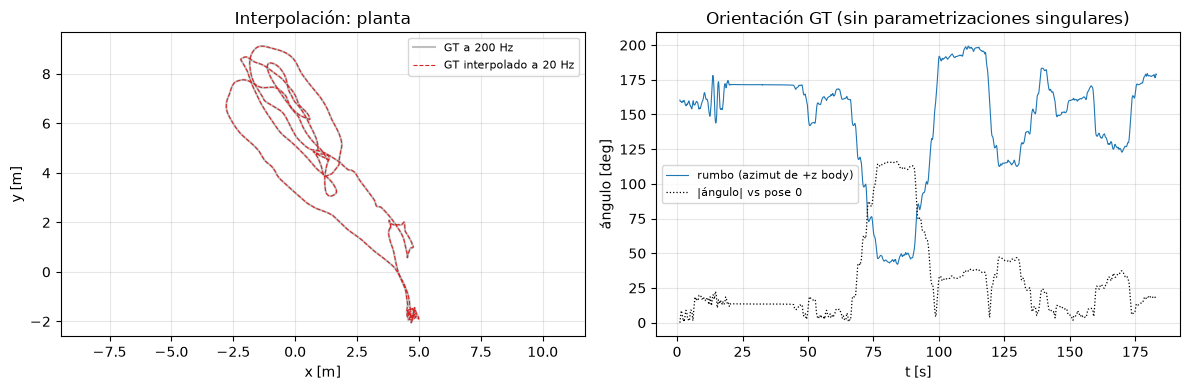

In [35]:
# Verificación de que la interpolación no ha destrozado nada: comparar la
# trayectoria interpolada contra la original a 200 Hz.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(gt_p[:, 0], gt_p[:, 1], lw=1.5, c="0.75", label="GT a 200 Hz")
axes[0].plot(gt_p_cam[:, 0], gt_p_cam[:, 1], lw=0.8, c="C3", ls="--",
             label="GT interpolado a 20 Hz")
axes[0].set_xlabel("x [m]"); axes[0].set_ylabel("y [m]")
axes[0].set_title("Interpolación: planta"); axes[0].axis("equal")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# POR QUÉ SE QUITAN LOS EULER ZYX CRUDOS. En esta secuencia pitch y roll son
# planos (~-74 y ~-175 deg): eso NO es el dron dando volteretas, es el MONTAJE
# de la IMU. El eje +x del body apunta al 96% hacia arriba. El problema es que
# ese montaje deja el pitch a sólo 15.6 deg de la singularidad de ZYX
# (pitch = -90), con un factor de amplificación 1/cos(74.4) = 3.7. Por eso el
# yaw sale dentado y oscila 200 deg mientras el giro total real no pasa de 50.
# np.unwrap arregla el envolvimiento, pero NO el mal condicionamiento.
#
# Dos curvas que sí están bien definidas siempre:

# A) Rumbo físico. El eje +z del body es casi horizontal (componente vertical
#    -0.26), así que su azimut en el plano xy del mundo es un rumbo bien
#    condicionado y con significado: hacia dónde mira el dron.
ez_world = gt_R_cam.apply([0.0, 0.0, 1.0])
rumbo = np.degrees(np.unwrap(np.arctan2(ez_world[:, 1], ez_world[:, 0])))

# B) Ángulo total respecto a la primera pose. Norma del vector de rotación:
#    un solo número, sin singularidades ni envolvimientos.
ang_total = np.degrees(np.linalg.norm((gt_R_cam[0].inv() * gt_R_cam).as_rotvec(), axis=1))

axes[1].plot(t_cam_gt, rumbo, lw=0.8, c="C0", label="rumbo (azimut de +z body)")
axes[1].plot(t_cam_gt, ang_total, lw=0.9, c="k", ls=":", label="|ángulo| vs pose 0")
axes[1].set_xlabel("t [s]"); axes[1].set_ylabel("ángulo [deg]")
axes[1].set_title("Orientación GT (sin parametrizaciones singulares)")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

# Si aun así quieres ver ángulos de Euler, hazlo sobre la rotación RELATIVA a la
# primera pose: al quitar el montaje los tres quedan pequeños (<50 deg) y muy
# lejos de cualquier singularidad.
#   R_rel = gt_R_cam[0].inv() * gt_R_cam
#   euler_rel = np.degrees(np.unwrap(R_rel.as_euler("ZYX"), axis=0))
 
plt.tight_layout()
plt.show()

## 1.9 - Calibración

Se carga aquí para guardarla junto al resto, pero su uso real es la Fase 2.
Lo único que se hace ahora es validar que la matriz es una transformada rígida
legítima: rotación ortonormal con determinante +1. Si el `reshape` fuese
incorrecto (EuRoC guarda los datos en row-major) esta comprobación fallaría.

In [36]:
with open(MAV0 / "cam0/sensor.yaml") as f:
    cfg_cam = yaml.safe_load(f)
with open(MAV0 / "imu0/sensor.yaml") as f:
    cfg_imu = yaml.safe_load(f)

In [37]:
fu, fv, cu, cv = cfg_cam["intrinsics"]
K = np.array([[fu, 0.0, cu],
              [0.0, fv, cv],
              [0.0, 0.0, 1.0]])
dist = np.array(cfg_cam["distortion_coefficients"])   # (k1, k2, p1, p2)

In [38]:
# T_BS: transformada del body frame (que en EuRoC ES el frame del IMU) al sensor.
T_imu_cam = np.array(cfg_cam["T_BS"]["data"]).reshape(4, 4)
T_BS_imu = np.array(cfg_imu["T_BS"]["data"]).reshape(4, 4)
 
R_ic = T_imu_cam[:3, :3]
assert np.allclose(R_ic.T @ R_ic, np.eye(3), atol=1e-6), "R de T_BS no es ortonormal"
assert np.isclose(np.linalg.det(R_ic), 1.0, atol=1e-6), "det(R) != +1"
assert np.allclose(T_BS_imu, np.eye(4)), "T_BS del IMU no es la identidad"

In [39]:
print("K =\n", K)
print("distorsión (k1,k2,p1,p2) =", dist)
print("T_imu_cam =\n", T_imu_cam)
print(f"baseline IMU-cámara: {np.linalg.norm(T_imu_cam[:3, 3]) * 100:.2f} cm")

K =
 [[458.654   0.    367.215]
 [  0.    457.296 248.375]
 [  0.      0.      1.   ]]
distorsión (k1,k2,p1,p2) = [-0.2834  0.074   0.0002  0.    ]
T_imu_cam =
 [[ 0.0149 -0.9999  0.0041 -0.0216]
 [ 0.9996  0.015   0.0257 -0.0647]
 [-0.0258  0.0038  0.9997  0.0098]
 [ 0.      0.      0.      1.    ]]
baseline IMU-cámara: 6.89 cm


In [40]:
ruido_imu = {k: cfg_imu[k] for k in ["gyroscope_noise_density", "gyroscope_random_walk",
                                     "accelerometer_noise_density", "accelerometer_random_walk"]}
print("\nParámetros de ruido de la IMU:", ruido_imu)


Parámetros de ruido de la IMU: {'gyroscope_noise_density': 0.00016968, 'gyroscope_random_walk': 1.9393e-05, 'accelerometer_noise_density': 0.002, 'accelerometer_random_walk': 0.003}


## 1.10 - Guardar el resultado

Se persiste todo en un `.npz` para que las fases siguientes no vuelvan a
parsear CSVs ni a recalcular la sincronización. Además, así queda congelado el
origen de tiempos `T0_NS`, que es la fuente de desalineamientos más tonta y más
difícil de detectar si cada notebook lo recalcula a su manera.

In [41]:
SALIDA.parent.mkdir(parents=True, exist_ok=True)
np.savez_compressed(
    SALIDA,
    # tiempos (relativos a T0_NS) y el propio origen
    T0_ns=T0_NS,
    t_imu=t_imu, t_cam=t_cam, t_gt=t_gt,
    # IMU
    gyro=gyro, accel=accel,
    # asociación IMU <-> frames
    imu_ini=imu_ini, imu_fin=imu_fin,
    # imágenes
    rutas_img=rutas_img,
    # ground truth original (200 Hz)
    gt_p=gt_p, gt_q_wxyz=q_wxyz, gt_v=gt_v, gt_bw=gt_bw, gt_ba=gt_ba,
    # ground truth interpolado en instantes de cámara
    mask_gt=mask_gt, t_cam_gt=t_cam_gt,
    gt_p_cam=gt_p_cam, gt_q_cam_wxyz=gt_q_cam_wxyz, gt_v_cam=gt_v_cam,
    # inicialización del tramo estático (para la Fase 3)
    i0_estatico=I0, i1_estatico=I1,
    t_estatico=np.array([t_est0, t_est1]),
    bias_giro_est=bias_giro_est, sigma_bias_giro=sigma_bias_giro,
    accel_medio_est=accel_medio_est, g_body=g_body,
    roll0=roll0, pitch0=pitch0,
    # el residuo del test de gravedad = R_wb @ b_a. Guardarlo deja constancia
    # de cuánto bias del acelerómetro se ha colado dentro de g_body.
    residuo_gravedad=residuo,
    # arranque del estimador: dato DISTINTO del fin del reposo
    t_motores=t_motores, t_despegue=t_despegue, t_arranque=t_arranque,
    # calibración
    K=K, dist=dist, T_imu_cam=T_imu_cam,
    **{f"ruido_{k}": v for k, v in ruido_imu.items()},
)
print(f"Guardado en {SALIDA}  ({SALIDA.stat().st_size / 1e6:.1f} MB)")

Guardado en ..\results\MH_01_easy\fase1_sync.npz  (3.0 MB)


## Test de aceptación de la Fase 1

Antes de pasar a la Fase 2, deberías poder responder a esto sin dudar:

1. ¿Cuántas muestras de IMU tiene el frame 100, y cuáles son sus índices? -> 10 muestras de IMU, empezando del frame 1000 hasta el 1009. La razon es que la IMU arranca antes que la cámara. Mirando los datos, t_imu[0] = 49.9999ns antes de t_cam[0], es decir, 10 mueshtras de imu antes. En la celda 1.7 se puede ver.
2. ¿Por qué la posición del GT y la trayectoria de la cámara no empiezan en el
   mismo instante? -> porque el GT y la cámara no se recogen en el drone, el GT se calcula respecto a un punto arbitrario de la sala y la camara la gestiona el drone, por lo que no tienen por que estar referenciados temporalmente.
3. ¿Qué pasaría si en la celda 1.7 usaras `side="left"` en lugar de `"right"`? -> por izquierda tomaria todos los que sean mayores, por lo que se tomaria de la posicion N hasta la ultima
4. ¿Por qué SLERP y no `np.interp` para el cuaternión? -> si se promedia con interp, el resultado no da 1 y ya no es un cuaternion valido
5. ¿En qué instante deja el dron de estar quieto, y por qué eso condiciona dónde puedes arrancar un VIO monocular? -> cuando el valor de aceleracion absoluta del dron deja de ser de 9.8m/s2 en direccion negativa.

Si alguna no está clara, vuelve a la celda correspondiente antes de seguir.